# Import the Dataset and Clean it

In [1]:
import pandas as pd

# Load the dataset 
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first few rows of the dataset
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
# Display the summary information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# Noticed "TotalCharges" column is object type because some values are " ",
# as an empty string, let's convert it to numeric and check for missing values.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now we Check for missing values
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [4]:
# Now that we have shown there are missing values, we will delete them since its only 11 rows out of 7043.
df.dropna(inplace=True)

# Chceking again for missing values to confirm they are deleted.
print(df.isnull().sum())

# Now we will check for duplicates in the dataset.
print("\n ---- Duplicates : " + str(df.duplicated().sum()))

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

 ---- Duplicates : 0


# Visualizing the Data to see the Relations between the Features

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the theme for seaborn
sns.set_theme(style="whitegrid")

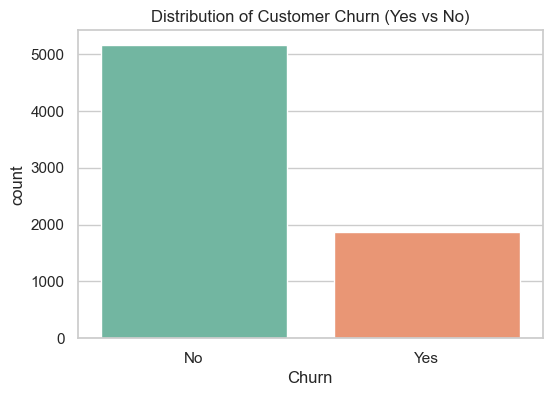

In [6]:
# Visual showing how many of the customers ended their subscription (churned) vs how many stayed (not churned).
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribution of Customer Churn (Yes vs No)')
plt.show()

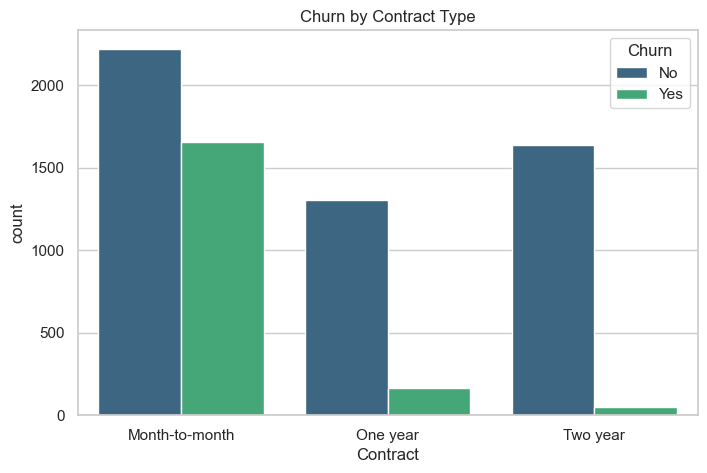

In [7]:
# Showing if the contract type has a role in customer churn.

# No : the customer did not end the subscription | Yes : the customer ended the subscription.
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn by Contract Type')
plt.show()

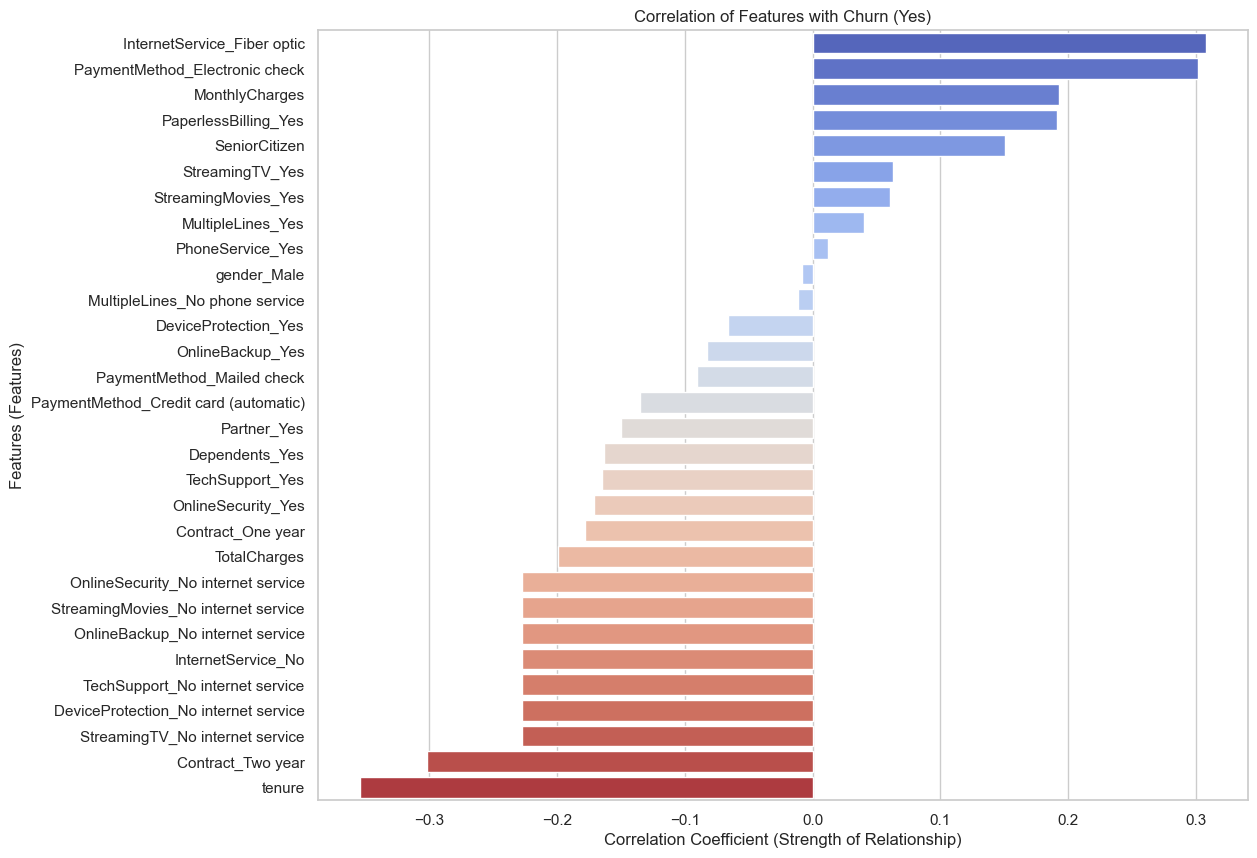

In [46]:
# firstly: encoding the categorical variables using one-hot encoding
# and dropping the 'customerID' column since it is not useful for analysis.
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), drop_first=True)

# Now we will calculate the correlation of each feature with the target variable 'Churn_Yes' and visualize it using a bar plot.
plt.figure(figsize=(12, 10))


# Calculate the correlation with the target variable (Churn_Yes)
correlation = df_encoded.corr()['Churn_Yes'].sort_values(ascending=False)

# Exclude the target variable itself from the plot
correlation = correlation.drop('Churn_Yes')

# Create a bar plot of the correlation values
sns.barplot(x=correlation.values, y=correlation.index, hue=correlation.index, palette='coolwarm', legend=False)

plt.title('Correlation of Features with Churn (Yes)')
plt.xlabel('Correlation Coefficient (Strength of Relationship)')
plt.ylabel('Features (Features)')
plt.show()


# Reducing Features

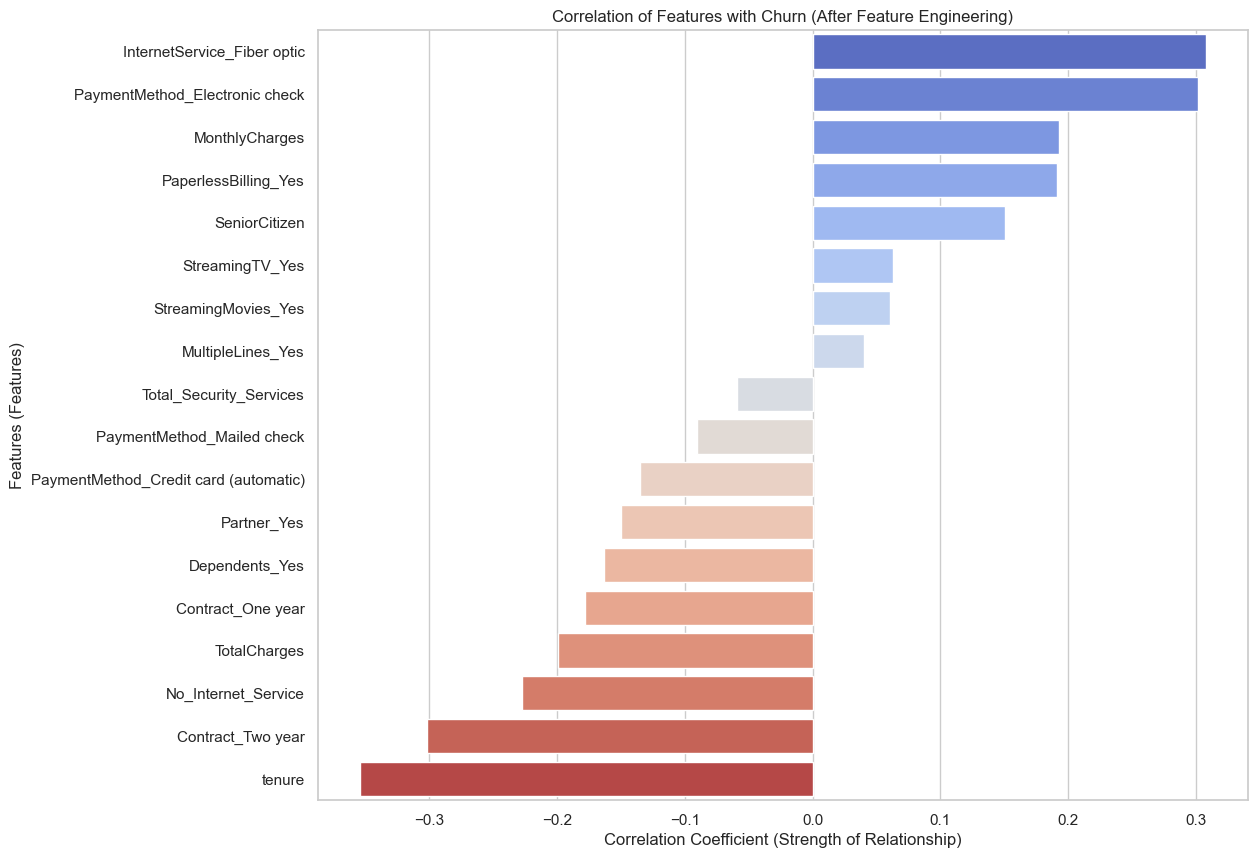

In [50]:
# Merging related features into new features to reduce dimensionality and potentially improve model performance. 
df_encoded['Total_Security_Services'] = (
    df_encoded['OnlineSecurity_Yes'] + 
    df_encoded['OnlineBackup_Yes'] + 
    df_encoded['DeviceProtection_Yes'] + 
    df_encoded['TechSupport_Yes']
)
df_encoded['No_Internet_Service'] = (
    df_encoded['OnlineSecurity_No internet service'] + 
    df_encoded['OnlineBackup_No internet service'] + 
    df_encoded['DeviceProtection_No internet service'] + 
    df_encoded['TechSupport_No internet service'] +
    df_encoded['StreamingTV_No internet service'] +
    df_encoded['StreamingMovies_No internet service'] +
    df_encoded['InternetService_No']
)

# dropping the original features that were combined into the new features, as well as some other features that have low correlation with the target variable.
columns_to_drop = [
    'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes',
    'gender_Male', 'PhoneService_Yes', 'MultipleLines_No phone service' ,'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service',
    'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'InternetService_No'
]

# Showing the new features and the remaining features after dropping the original ones.
df_final = df_encoded.drop(columns=columns_to_drop)
plt.figure(figsize=(12, 10))

# 1. حساب الارتباط من البيانات النهائية (اللي فيها الميزة المدمجة وبدون المميزات الضعيفة)
correlation_final = df_final.corr()['Churn_Yes'].sort_values(ascending=False)

# 2. استبعاد الهدف نفسه
correlation_final = correlation_final.drop('Churn_Yes')

# 3. رسم خريطة الارتباط الجديدة
sns.barplot(x=correlation_final.values, y=correlation_final.index, hue=correlation_final.index, palette='coolwarm', legend=False)

plt.title('Correlation of Features with Churn (After Feature Engineering)')
plt.xlabel('Correlation Coefficient (Strength of Relationship)')
plt.ylabel('Features (Features)')
plt.show()

# Training Models And Comparing them

In [58]:
# Now after feature engineering,
# we can see that the new features "Total_Security_Services" and "No_Internet_Service" have a stronger correlation with the target variable "Churn_Yes" compared to the original features.
# This indicates that these new features may be more informative for predicting customer churn.

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df_final.drop('Churn_Yes', axis=1), df_final['Churn_Yes'], test_size=0.2, random_state=42)

# 1. Initialize the models
RF_model = RandomForestClassifier(random_state=42)
XGB_model = XGBClassifier(random_state=42, eval_metric='logloss')

# 2. Train the models using the training data
print("Training models...")
RF_model.fit(x_train, y_train)
XGB_model.fit(x_train, y_train)

# 3 Evaluate the models using the test data
RF_predictions = RF_model.predict(x_test)
XGB_predictions = XGB_model.predict(x_test)

# 4. Calculate the accuracy of each model
print("Calculating accuracy...")

RF_accuracy = accuracy_score(y_test, RF_predictions)
print(f"Random Forest Accuracy: {RF_accuracy}")

XGB_accuracy = accuracy_score(y_test, XGB_predictions)
print(f"XGBoost Accuracy: {XGB_accuracy}")


Training models...
Calculating accuracy...
Random Forest Accuracy: 0.7775408670931059
XGBoost Accuracy: 0.7746979388770433


# Trying The best Parameters for XGBoost

In [79]:
from sklearn.model_selection import GridSearchCV # Importing GridSearchCV for hyperparameter tuning

# 2. Define the hyperparameter grid to search
# Think of these as the "knobs" we are tuning
param_grid = {
    'n_estimators': [10,50, 100, 200],      # Number of trees to build
    'max_depth': [3, 4, 5],              # Maximum depth of each tree (controls overfitting)
    'learning_rate': [0.001, 0.01, 0.1]   # Step size at each iteration
}

# 3. Set up the Grid Search
# cv=5 means 5-fold Cross-Validation (validating the results 5 times for each combination)
# n_jobs=-1 uses all your computer's CPU cores to speed up the process
grid_search = GridSearchCV(estimator=XGB_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)    

# 4. Run the search (This will test 3x3x3 = 27 combinations)
print("Starting Hyperparameter Tuning... This might take a minute ⏳")
grid_search.fit(x_train, y_train)

# 5. Extract the best model found
best_xgb_model = grid_search.best_estimator_

# 6. Evaluate the new, tuned model on our test data
best_predictions = best_xgb_model.predict(x_test)
best_accuracy = accuracy_score(y_test, best_predictions)

# 7. Print the glorious results
print("\n--- Tuning Completed! ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Old XGBoost Accuracy: {XGB_accuracy} + 77% accuracy")
print(f"Tuned XGBoost Accuracy: {best_accuracy} + almost 80% accuracy! 🎉")

Starting Hyperparameter Tuning... This might take a minute ⏳
Fitting 5 folds for each of 36 candidates, totalling 180 fits

--- Tuning Completed! ---
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Old XGBoost Accuracy: 0.7746979388770433 + 77% accuracy
Tuned XGBoost Accuracy: 0.7938877043354655 + almost 80% accuracy! 🎉
